In [146]:
import matplotlib.pyplot as plt
import numpy as np

In [147]:
def func(t,y):
  return t*np.exp(3*t) - 2 * y

In [148]:
def real_func(t):
    return (1/5)*t*np.exp(3*t) - (1/25)*np.exp(3*t) + (1/25)*np.exp(-2*t)

In [149]:
def runge_kutta_2(Ti,Tf,y0,h,function):
  N = int(np.ceil((Tf - Ti)/h))
  t = np.zeros(N + 1)
  y = np.zeros(N + 1)
  y[0] = y0
  t[0] = Ti
  for i in range(N):
    y[i + 1] = y[i] + h*function(t[i] + h/2, y[i] + (h/2)*function(t[i],y[i]))
    t[i + 1] = t[i] + h
  return t,y;

In [150]:
runge_kutta_2(0,2,0.5,0.2,func)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 array([  0.5       ,   0.36699718,   0.38255732,   0.65518601,
          1.44359874,   3.30725721,   7.41029399,  16.12692142,
         34.23701142,  71.27194953, 146.09327608]))

In [151]:
def runge_kutta_4(Ti,Tf,y0,h,function):
  N = int(np.ceil((Tf - Ti)/h))
  t = np.zeros(N + 1)
  y = np.zeros(N + 1)
  y[0] = y0
  t[0] = Ti
  for i in range(N):
    k1 = h*function(t[i],y[i])
    k2 = h*function(t[i] + h/2, y[i] + (1/2)*k1)
    k3 = h*function(t[i] + h/2, y[i] + (1/2)*k2)
    t[i + 1] = t[i] + h
    k4 = h*function(t[i + 1],y[i] + k3)
    y[i + 1] = y[i] + (1/6)*(k1 + 2*k2 + 2*k3 + k4)
  return t,y

In [152]:
runge_kutta_4(0,2,0.5,0.2,func)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 array([  0.5       ,   0.36210591,   0.37576493,   0.64729886,
          1.43322405,   3.28970061,   7.37465126,  16.04977886,
         34.06952399,  70.91388795, 145.34147643]))

In [153]:
h_ = [0.5]

In [154]:
def real_plot(Ti,Tf,function):
    t = np.linspace(Ti,Tf)
    y = function(t)
    plt.plot(t,y, label = "Real function")

In [155]:
def aprox_plot(Ti,Tf,y0,function):
    for step in h_:
        t2,y2 = runge_kutta_2(Ti,Tf,y0,step,function)
        t4,y4 = runge_kutta_4(Ti,Tf,y0,step,function)
        plt.scatter(t2,y2,label = "Runge-kutta 2")
        plt.scatter(t4,y4,label = "Runge-kutta 4")
    real_plot(Ti,Tf,real_func)
    plt.legend()
    plt.grid()
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

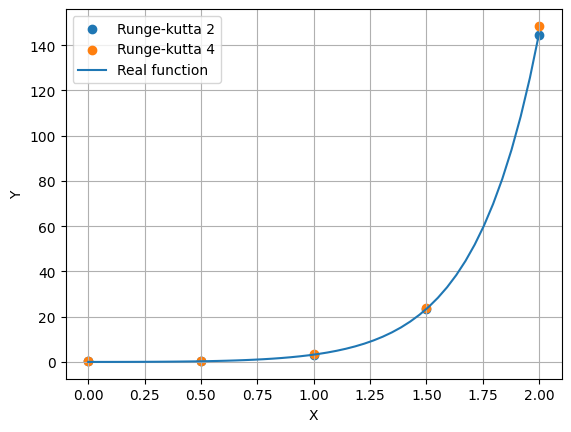

In [156]:
aprox_plot(0,2,0.5,func)